# Serialization Format Analysis: JSON vs BSON

Metrics ranked by priority:
1. **Deserialization Time** — most frequently repeated cost
2. **Payload Size** — determines transmission time & buffer allocation
3. **Serialization Time** — incurred once per origin service
4. **Memory Consumption** — relevant in constrained deployments
5. **Total Processing Time** — composite / aggregate view

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
})

COLORS = {'JSON': '#3274A1', 'BSON': '#E1812C'}
SAVE = True
OUT_DIR = 'first_assignment/plots_output'
os.makedirs(OUT_DIR, exist_ok=True)

def savefig(fig, name):
    if SAVE:
        fig.savefig(f'{OUT_DIR}/{name}.pdf', bbox_inches='tight')
        fig.savefig(f'{OUT_DIR}/{name}.png', bbox_inches='tight')

In [18]:
# ── Load & preprocess ──────────────────────────────────────────
df = pd.read_csv('first_assignment/stats.csv')
df['ram_MB'] = df['ram_bytes'] / (1024**2)
df['message_size_KB'] = df['message_size_bytes'] / 1024

# Aggregate: mean ± std per (format, numChunks, service)
group_cols = ['format', 'numChunks', 'service']
agg = df.groupby(group_cols).agg(
    deser_mean=('deserialization_ms', 'mean'),
    deser_std=('deserialization_ms', 'std'),
    ser_mean=('serialization_ms', 'mean'),
    ser_std=('serialization_ms', 'std'),
    total_mean=('total_ms', 'mean'),
    total_std=('total_ms', 'std'),
    ram_mean=('ram_MB', 'mean'),
    ram_std=('ram_MB', 'std'),
    size_mean=('message_size_KB', 'mean'),  # constant per group anyway
).reset_index()

# Aggregate across all services (format × numChunks)
agg_all = df.groupby(['format', 'numChunks']).agg(
    deser_mean=('deserialization_ms', 'mean'),
    deser_std=('deserialization_ms', 'std'),
    ser_mean=('serialization_ms', 'mean'),
    ser_std=('serialization_ms', 'std'),
    total_mean=('total_ms', 'mean'),
    total_std=('total_ms', 'std'),
    ram_mean=('ram_MB', 'mean'),
    ram_std=('ram_MB', 'std'),
    size_mean=('message_size_KB', 'mean'),
).reset_index()

chunks = sorted(df['numChunks'].unique())
services = sorted(df['service'].unique())
formats = ['JSON', 'BSON']

# Chunks present in BOTH formats (for side-by-side comparisons)
json_chunks = set(df[df['format'] == 'JSON']['numChunks'].unique())
bson_chunks = set(df[df['format'] == 'BSON']['numChunks'].unique())
common_chunks = sorted(json_chunks & bson_chunks)

print(f'Rows: {len(df)} | Formats: {formats} | Chunk sizes: {chunks} | Common: {common_chunks} | Services: {services}')

Rows: 120 | Formats: ['JSON', 'BSON'] | Chunk sizes: [np.int64(10), np.int64(20), np.int64(50), np.int64(80), np.int64(100), np.int64(120), np.int64(150), np.int64(180)] | Common: [np.int64(10), np.int64(20), np.int64(50), np.int64(80), np.int64(100), np.int64(120)] | Services: ['AudioService', 'MetadataService', 'VideoService']


---
## 1 · Deserialization Time (Priority 1)

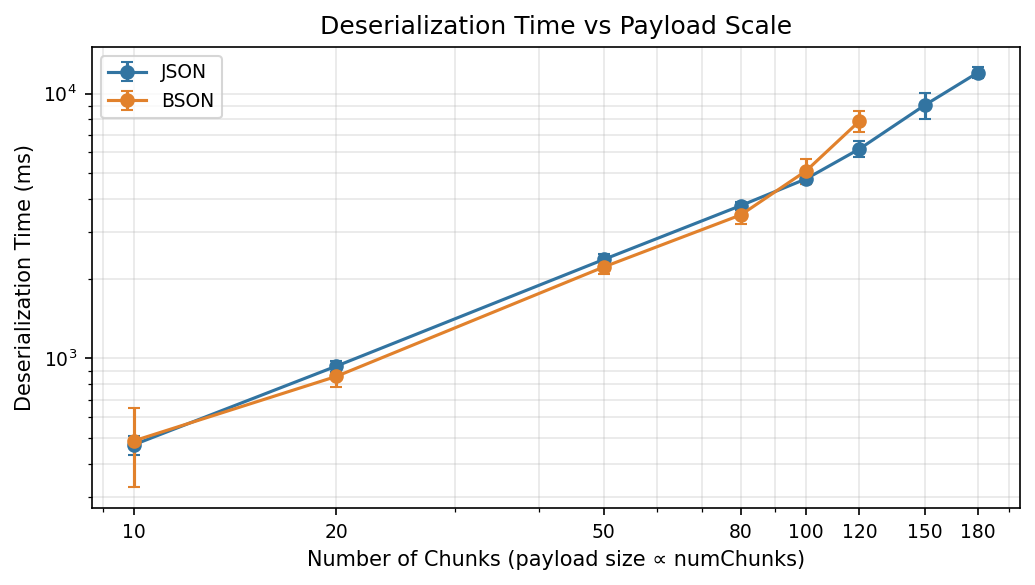

In [19]:
# ── 1a. Deserialization vs Payload Size (log-log) ──────────────
fig, ax = plt.subplots(figsize=(7, 4))
for fmt in formats:
    d = agg_all[agg_all['format'] == fmt]
    ax.errorbar(d['numChunks'], d['deser_mean'], yerr=d['deser_std'],
                marker='o', capsize=3, label=fmt, color=COLORS[fmt], linewidth=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Number of Chunks (payload size ∝ numChunks)')
ax.set_ylabel('Deserialization Time (ms)')
ax.set_title('Deserialization Time vs Payload Scale')
ax.set_xticks(chunks); ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.legend(); ax.grid(True, which='both', alpha=0.3)
fig.tight_layout(); savefig(fig, '1a_deserialization_vs_scale')
plt.show()

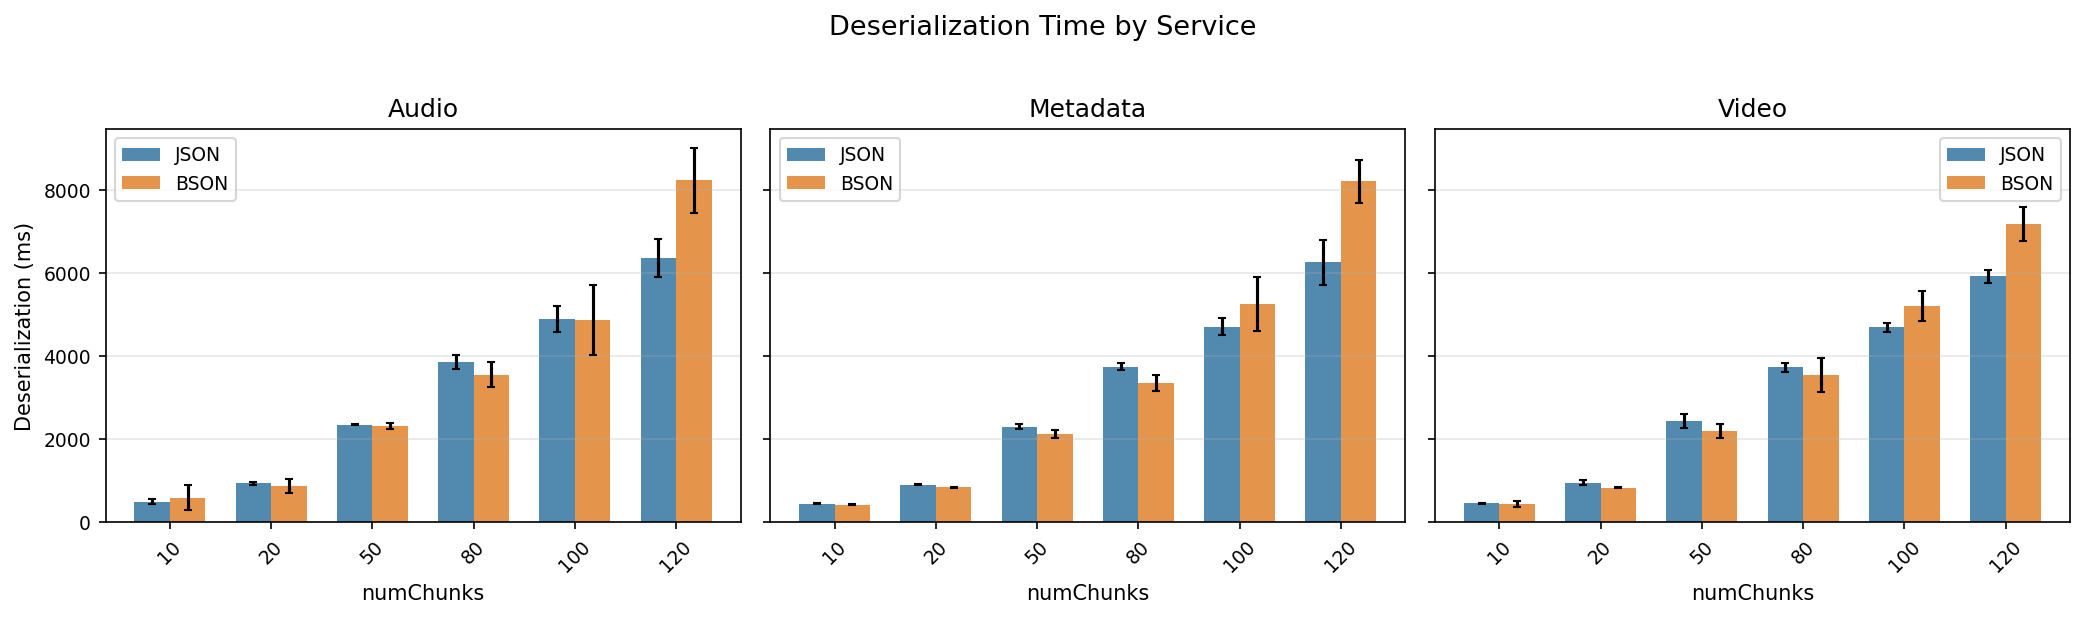

In [20]:
# ── 1b. Deserialization by service (grouped bars) ──────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
bar_w = 0.35
x = np.arange(len(common_chunks))
for i, svc in enumerate(services):
    ax = axes[i]
    for j, fmt in enumerate(formats):
        d = agg[(agg['format'] == fmt) & (agg['service'] == svc) & (agg['numChunks'].isin(common_chunks))]
        d = d.set_index('numChunks').loc[common_chunks].reset_index()
        ax.bar(x + j*bar_w, d['deser_mean'], bar_w, yerr=d['deser_std'],
               label=fmt, color=COLORS[fmt], capsize=2, alpha=0.85)
    ax.set_xticks(x + bar_w/2); ax.set_xticklabels(common_chunks, rotation=45)
    ax.set_xlabel('numChunks'); ax.set_title(svc.replace('Service', ''))
    if i == 0: ax.set_ylabel('Deserialization (ms)')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Deserialization Time by Service', fontsize=13, y=1.02)
fig.tight_layout(); savefig(fig, '1b_deserialization_by_service')
plt.show()

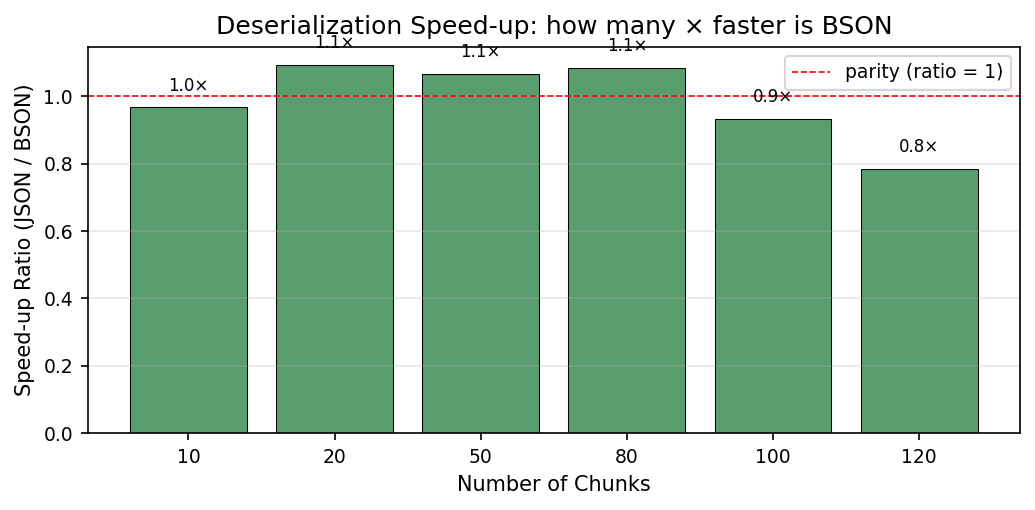

In [21]:
# ── 1c. Deserialization Speed-up ratio (BSON / JSON) ──────────
agg_common = agg_all[agg_all['numChunks'].isin(common_chunks)]
pivot_deser = agg_common.pivot(index='numChunks', columns='format', values='deser_mean')
pivot_deser['ratio'] = pivot_deser['JSON'] / pivot_deser['BSON']

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(range(len(common_chunks)), pivot_deser['ratio'].values, color='#5A9E6F', edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(common_chunks))); ax.set_xticklabels(common_chunks)
ax.axhline(1, color='red', linestyle='--', linewidth=0.8, label='parity (ratio = 1)')
ax.set_xlabel('Number of Chunks'); ax.set_ylabel('Speed-up Ratio (JSON / BSON)')
ax.set_title('Deserialization Speed-up: how many × faster is BSON')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for k, v in enumerate(pivot_deser['ratio'].values):
    ax.text(k, v + 0.05, f'{v:.1f}×', ha='center', fontsize=8)
fig.tight_layout(); savefig(fig, '1c_deserialization_speedup_ratio')
plt.show()

---
## 2 · Payload Size (Priority 2)

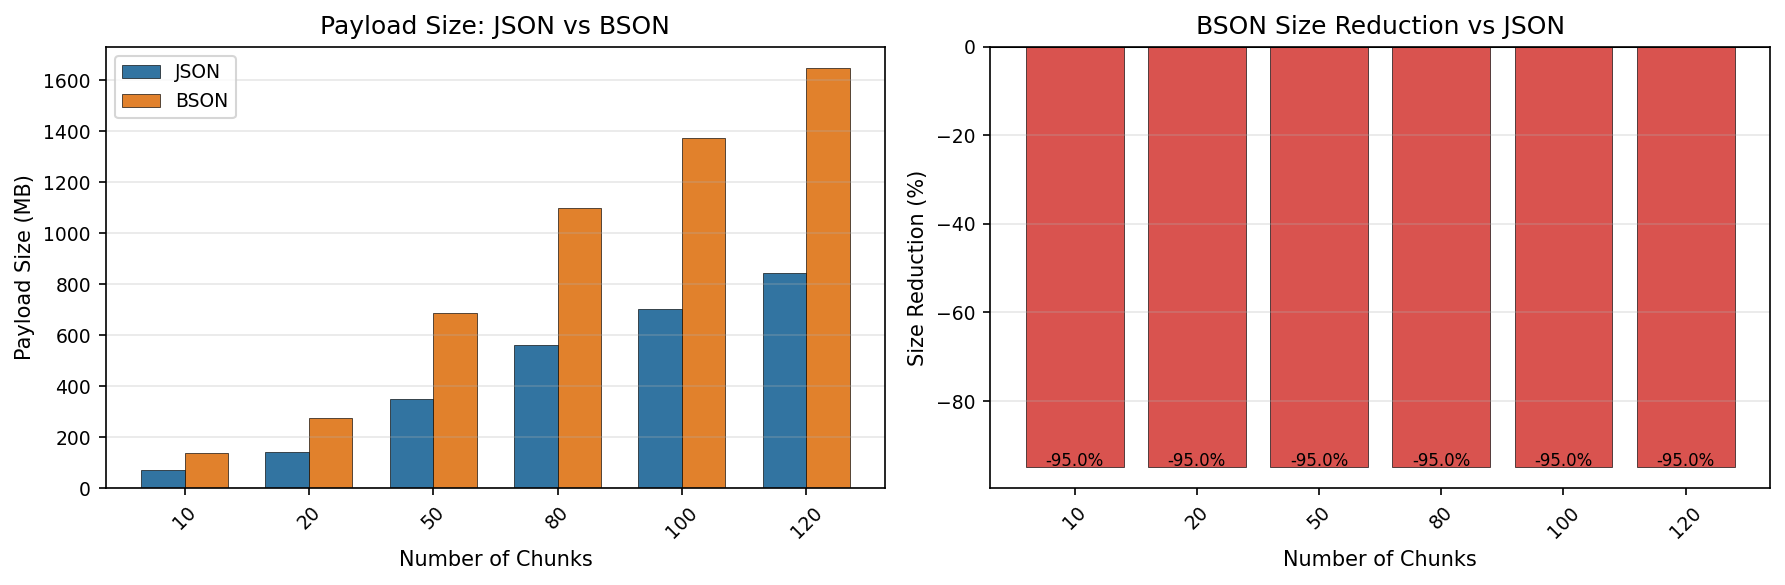

In [22]:
# ── 2a. Payload size comparison (JSON vs BSON) ────────────────
size_df = df.groupby(['format', 'numChunks'])['message_size_bytes'].first().reset_index()
size_common = size_df[size_df['numChunks'].isin(common_chunks)]
size_pivot = size_common.pivot(index='numChunks', columns='format', values='message_size_bytes')
size_pivot['reduction_%'] = (1 - size_pivot['BSON'] / size_pivot['JSON']) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: absolute sizes
bar_w = 0.35; x = np.arange(len(common_chunks))
for j, fmt in enumerate(formats):
    vals = size_pivot[fmt].values / (1024**2)  # MB
    ax1.bar(x + j*bar_w, vals, bar_w, label=fmt, color=COLORS[fmt], edgecolor='black', linewidth=0.3)
ax1.set_xticks(x + bar_w/2); ax1.set_xticklabels(common_chunks, rotation=45)
ax1.set_xlabel('Number of Chunks'); ax1.set_ylabel('Payload Size (MB)')
ax1.set_title('Payload Size: JSON vs BSON'); ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# Right: % reduction
colors_bar = ['#5A9E6F' if v > 0 else '#D9534F' for v in size_pivot['reduction_%'].values]
ax2.bar(range(len(common_chunks)), size_pivot['reduction_%'].values, color=colors_bar, edgecolor='black', linewidth=0.3)
ax2.set_xticks(range(len(common_chunks))); ax2.set_xticklabels(common_chunks, rotation=45)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_xlabel('Number of Chunks'); ax2.set_ylabel('Size Reduction (%)')
ax2.set_title('BSON Size Reduction vs JSON')
for k, v in enumerate(size_pivot['reduction_%'].values):
    ax2.text(k, v + 0.3, f'{v:.1f}%', ha='center', fontsize=8)
ax2.grid(axis='y', alpha=0.3)

fig.tight_layout(); savefig(fig, '2a_payload_size_comparison')
plt.show()

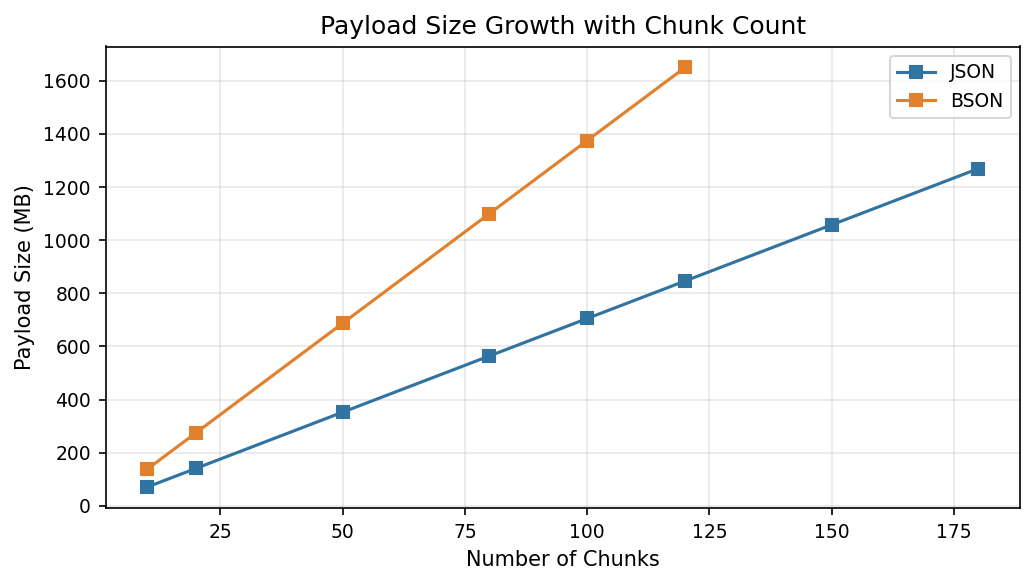

In [23]:
# ── 2b. Payload size growth (linearity check) ─────────────────
fig, ax = plt.subplots(figsize=(7, 4))
for fmt in formats:
    d = size_df[size_df['format'] == fmt].sort_values('numChunks')
    ax.plot(d['numChunks'], d['message_size_bytes'] / (1024**2),
            marker='s', label=fmt, color=COLORS[fmt], linewidth=1.5)
ax.set_xlabel('Number of Chunks'); ax.set_ylabel('Payload Size (MB)')
ax.set_title('Payload Size Growth with Chunk Count')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); savefig(fig, '2b_payload_size_growth')
plt.show()

---
## 3 · Serialization Time (Priority 3)

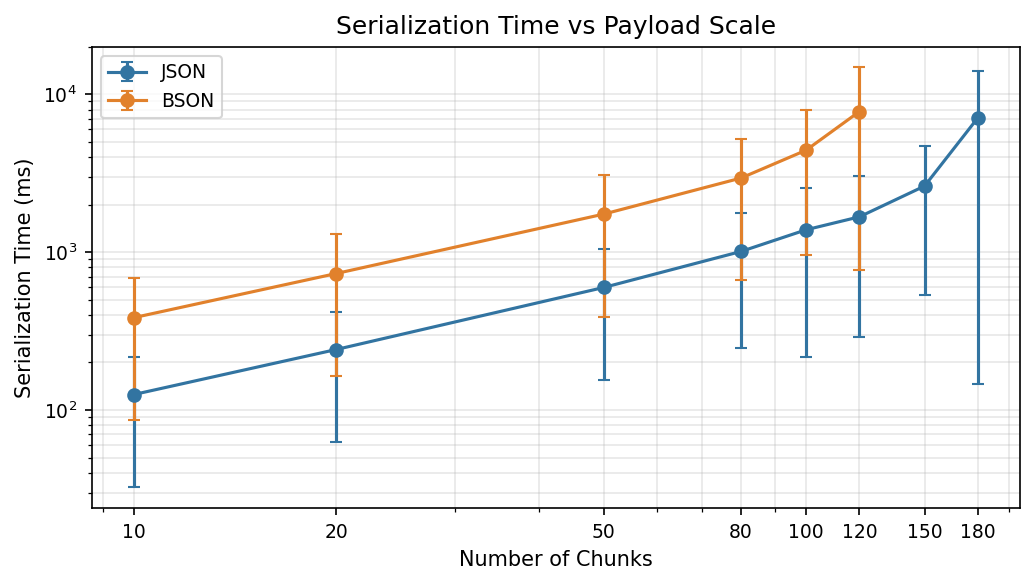

In [24]:
# ── 3a. Serialization vs Scale (log-log) ──────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
for fmt in formats:
    d = agg_all[agg_all['format'] == fmt]
    ax.errorbar(d['numChunks'], d['ser_mean'], yerr=d['ser_std'],
                marker='o', capsize=3, label=fmt, color=COLORS[fmt], linewidth=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Number of Chunks'); ax.set_ylabel('Serialization Time (ms)')
ax.set_title('Serialization Time vs Payload Scale')
ax.set_xticks(chunks); ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.legend(); ax.grid(True, which='both', alpha=0.3)
fig.tight_layout(); savefig(fig, '3a_serialization_vs_scale')
plt.show()

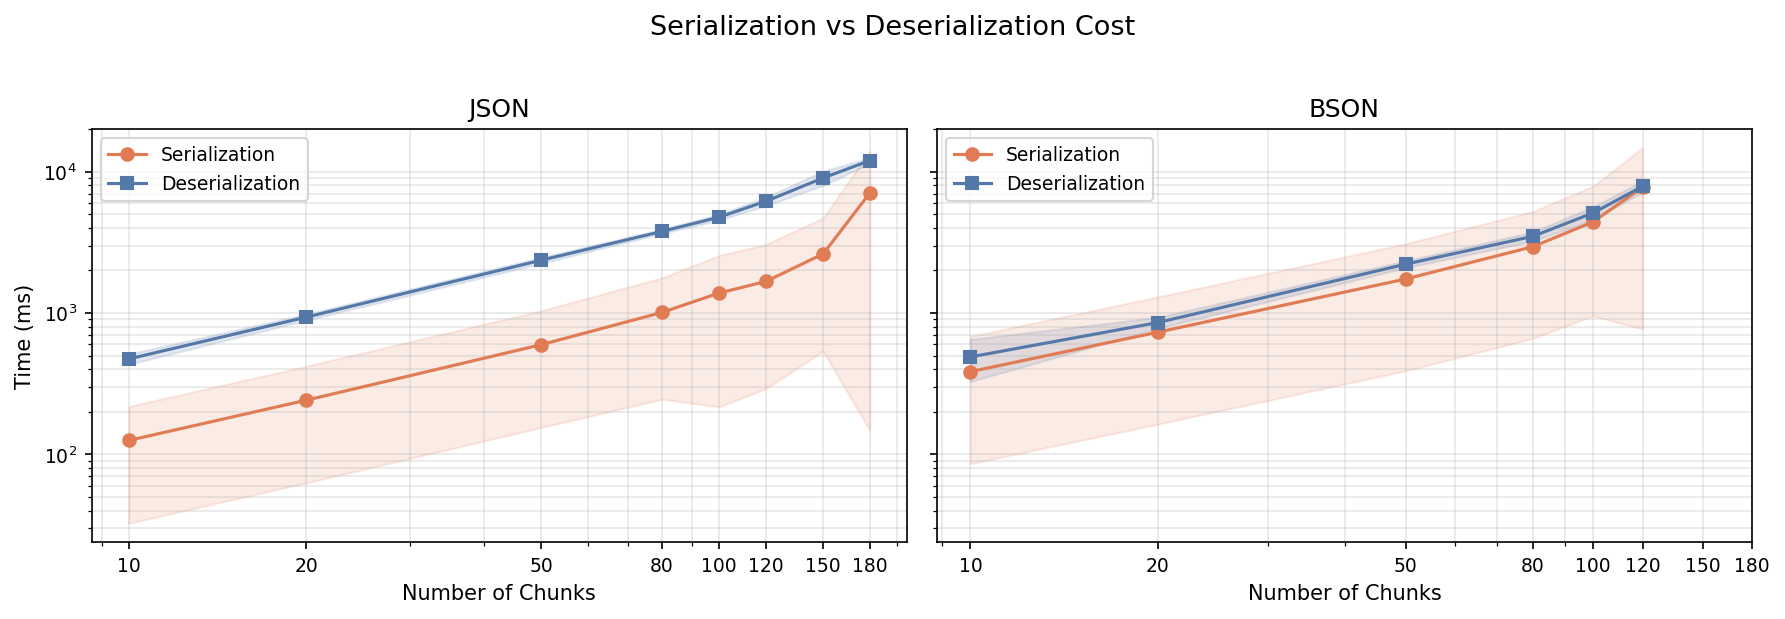

In [25]:
# ── 3b. Serialization vs Deserialization side-by-side ─────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for idx, fmt in enumerate(formats):
    ax = axes[idx]
    d = agg_all[agg_all['format'] == fmt]
    ax.plot(d['numChunks'], d['ser_mean'], marker='o', label='Serialization', color='#E07B54', linewidth=1.5)
    ax.plot(d['numChunks'], d['deser_mean'], marker='s', label='Deserialization', color='#5478A8', linewidth=1.5)
    ax.fill_between(d['numChunks'], d['ser_mean'] - d['ser_std'], d['ser_mean'] + d['ser_std'], alpha=0.15, color='#E07B54')
    ax.fill_between(d['numChunks'], d['deser_mean'] - d['deser_std'], d['deser_mean'] + d['deser_std'], alpha=0.15, color='#5478A8')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xticks(chunks); ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
    ax.set_xlabel('Number of Chunks'); ax.set_title(fmt)
    if idx == 0: ax.set_ylabel('Time (ms)')
    ax.legend(); ax.grid(True, which='both', alpha=0.3)
fig.suptitle('Serialization vs Deserialization Cost', fontsize=13, y=1.02)
fig.tight_layout(); savefig(fig, '3b_ser_vs_deser')
plt.show()

---
## 4 · Memory Consumption (Priority 4)

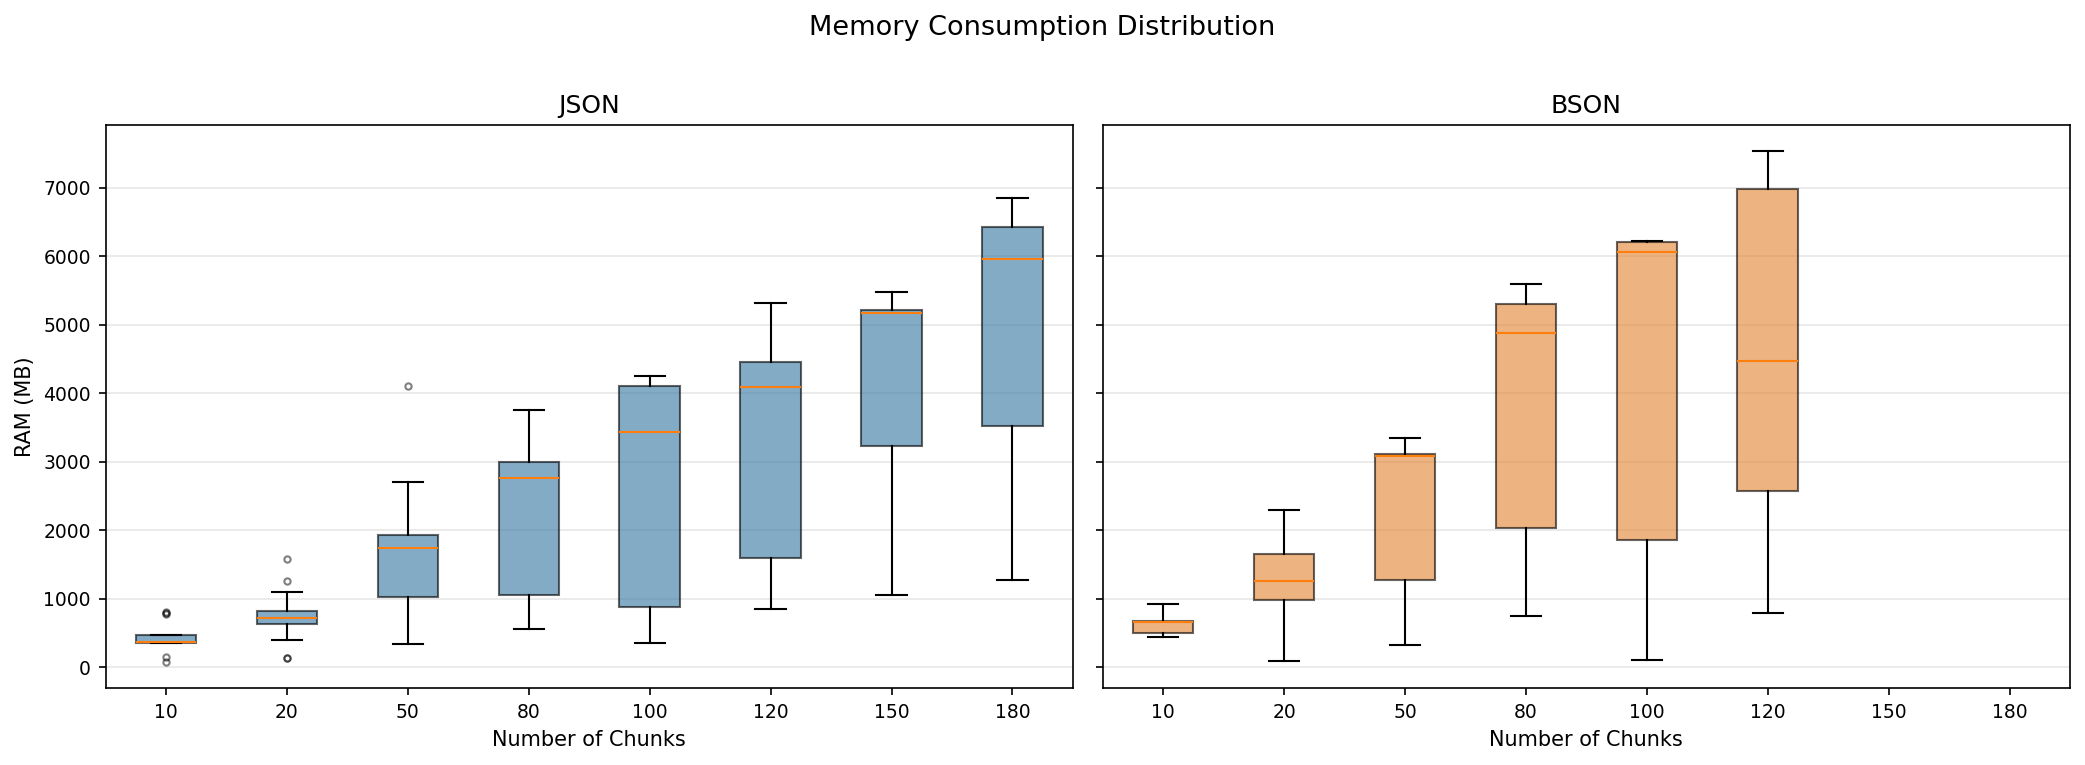

In [26]:
# ── 4a. Memory consumption box-plot per chunk size ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for idx, fmt in enumerate(formats):
    ax = axes[idx]
    data_boxes = [df[(df['format'] == fmt) & (df['numChunks'] == c)]['ram_MB'].values for c in chunks]
    bp = ax.boxplot(data_boxes, labels=chunks, patch_artist=True, showfliers=True,
                    flierprops=dict(markersize=3, alpha=0.5))
    for patch in bp['boxes']:
        patch.set_facecolor(COLORS[fmt]); patch.set_alpha(0.6)
    ax.set_xlabel('Number of Chunks'); ax.set_title(fmt)
    if idx == 0: ax.set_ylabel('RAM (MB)')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Memory Consumption Distribution', fontsize=13, y=1.01)
fig.tight_layout(); savefig(fig, '4a_memory_boxplot')
plt.show()

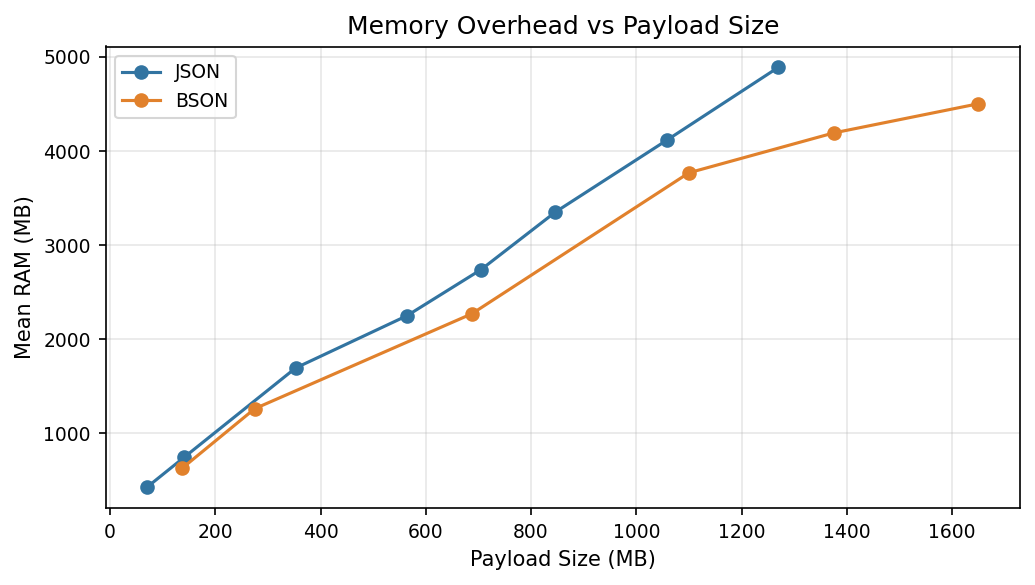

In [27]:
# ── 4b. Memory vs Payload Size (efficiency) ───────────────────
fig, ax = plt.subplots(figsize=(7, 4))
for fmt in formats:
    d = agg_all[agg_all['format'] == fmt].sort_values('numChunks')
    ax.plot(d['size_mean'] / 1024, d['ram_mean'],  # KB → MB for x
            marker='o', label=fmt, color=COLORS[fmt], linewidth=1.5)
ax.set_xlabel('Payload Size (MB)'); ax.set_ylabel('Mean RAM (MB)')
ax.set_title('Memory Overhead vs Payload Size')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); savefig(fig, '4b_memory_vs_payload')
plt.show()

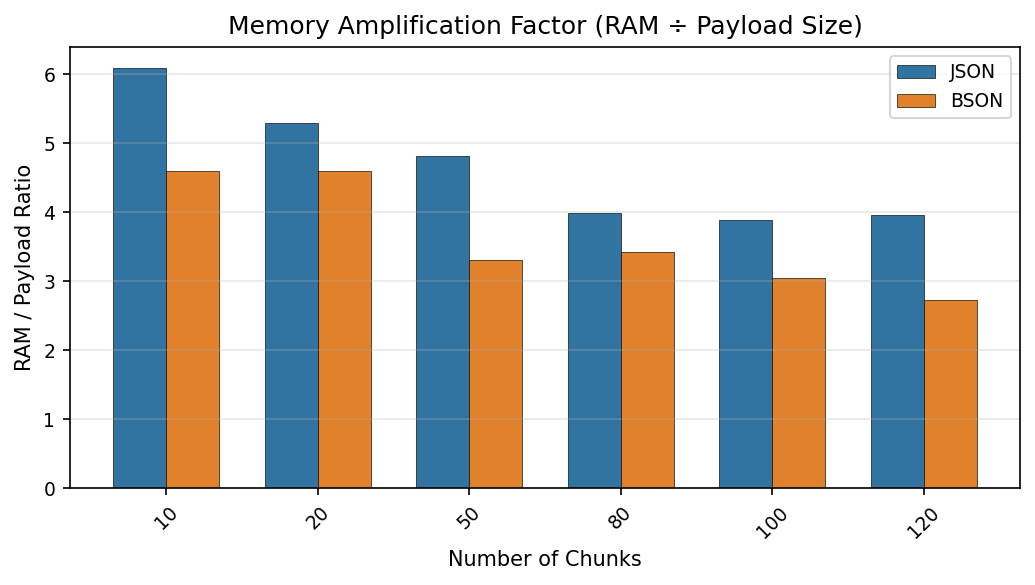

In [28]:
# ── 4c. Memory amplification factor ───────────────────────────
amp = agg_all[agg_all['numChunks'].isin(common_chunks)].copy()
amp['amplification'] = (amp['ram_mean'] * 1024) / amp['size_mean']  # RAM_KB / payload_KB

fig, ax = plt.subplots(figsize=(7, 4))
bar_w = 0.35; x = np.arange(len(common_chunks))
for j, fmt in enumerate(formats):
    d = amp[amp['format'] == fmt].sort_values('numChunks')
    ax.bar(x + j*bar_w, d['amplification'].values, bar_w,
           label=fmt, color=COLORS[fmt], edgecolor='black', linewidth=0.3)
ax.set_xticks(x + bar_w/2); ax.set_xticklabels(common_chunks, rotation=45)
ax.set_xlabel('Number of Chunks'); ax.set_ylabel('RAM / Payload Ratio')
ax.set_title('Memory Amplification Factor (RAM ÷ Payload Size)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
fig.tight_layout(); savefig(fig, '4c_memory_amplification')
plt.show()

---
## 5 · Total Processing Time (Priority 5)

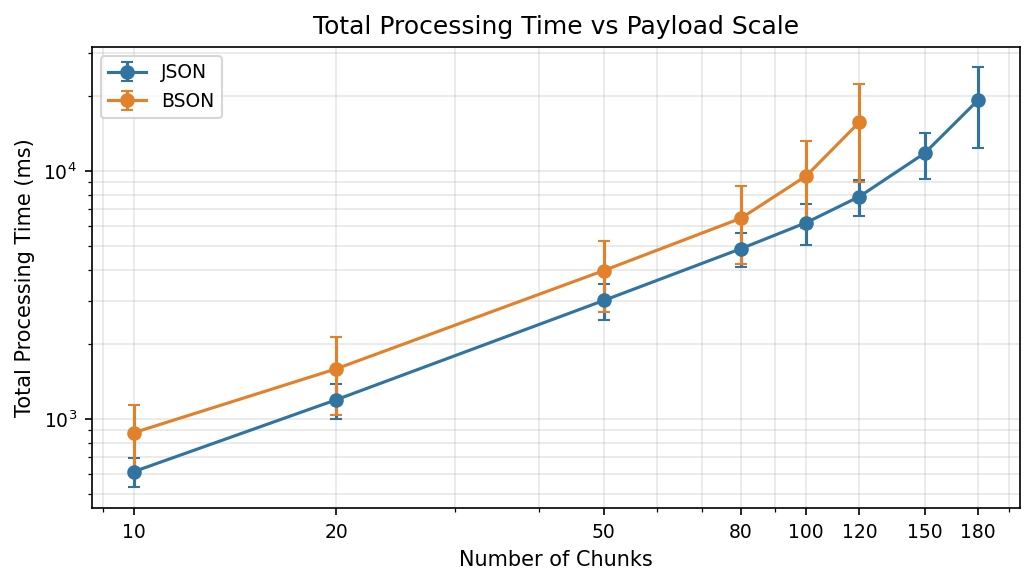

In [29]:
# ── 5a. Total time vs scale ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
for fmt in formats:
    d = agg_all[agg_all['format'] == fmt]
    ax.errorbar(d['numChunks'], d['total_mean'], yerr=d['total_std'],
                marker='o', capsize=3, label=fmt, color=COLORS[fmt], linewidth=1.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Number of Chunks'); ax.set_ylabel('Total Processing Time (ms)')
ax.set_title('Total Processing Time vs Payload Scale')
ax.set_xticks(chunks); ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.legend(); ax.grid(True, which='both', alpha=0.3)
fig.tight_layout(); savefig(fig, '5a_total_time_vs_scale')
plt.show()

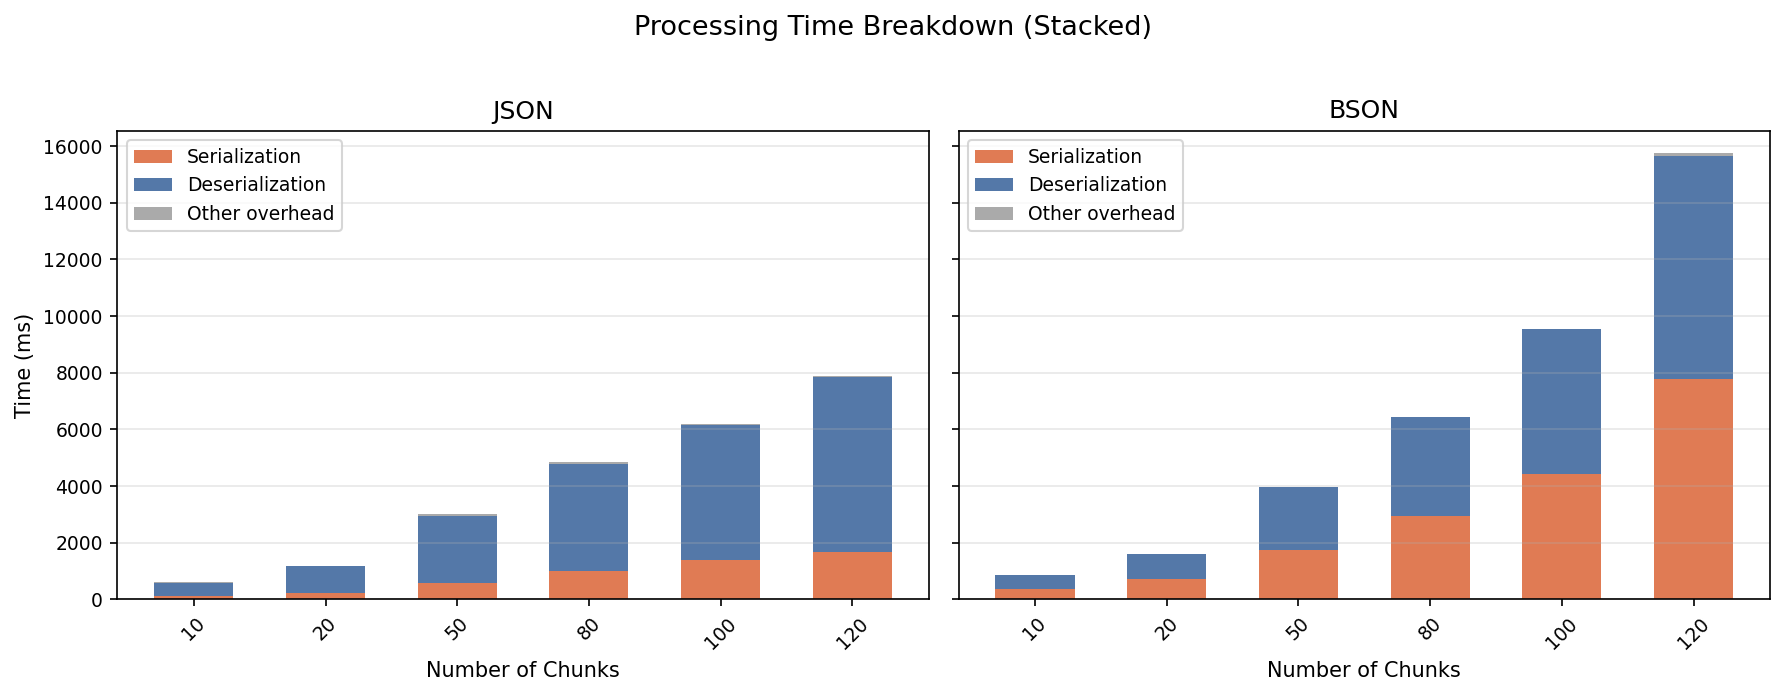

In [30]:
# ── 5b. Time breakdown: stacked bar (ser + deser) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
x = np.arange(len(common_chunks))
for idx, fmt in enumerate(formats):
    ax = axes[idx]
    d = agg_all[(agg_all['format'] == fmt) & (agg_all['numChunks'].isin(common_chunks))].sort_values('numChunks')
    ax.bar(x, d['ser_mean'], 0.6, label='Serialization', color='#E07B54')
    ax.bar(x, d['deser_mean'], 0.6, bottom=d['ser_mean'].values,
           label='Deserialization', color='#5478A8')
    overhead = d['total_mean'].values - d['ser_mean'].values - d['deser_mean'].values
    ax.bar(x, overhead, 0.6,
           bottom=d['ser_mean'].values + d['deser_mean'].values,
           label='Other overhead', color='#AAAAAA')
    ax.set_xticks(x); ax.set_xticklabels(common_chunks, rotation=45)
    ax.set_xlabel('Number of Chunks'); ax.set_title(fmt)
    if idx == 0: ax.set_ylabel('Time (ms)')
    ax.legend(loc='upper left'); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Processing Time Breakdown (Stacked)', fontsize=13, y=1.02)
fig.tight_layout(); savefig(fig, '5b_time_breakdown_stacked')
plt.show()

---
## 6 · Cross-Metric Comparison

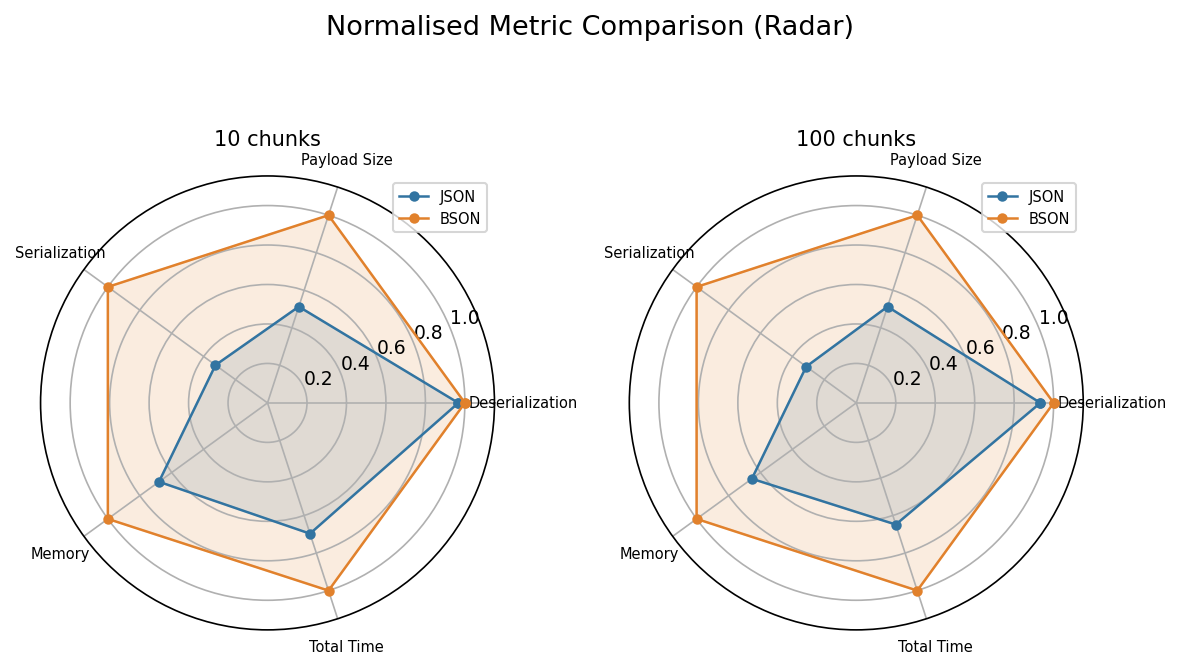

In [31]:
# ── 6a. Radar chart: normalised metrics at selected scales ────
from matplotlib.patches import FancyBboxPatch

selected_chunks = [c for c in [10, 100, 1000, 4000] if c in common_chunks]
if len(selected_chunks) < 2:
    selected_chunks = common_chunks[:4]  # fallback: first 4 common chunks
metrics = ['deser_mean', 'size_mean', 'ser_mean', 'ram_mean', 'total_mean']
metric_labels = ['Deserialization', 'Payload Size', 'Serialization', 'Memory', 'Total Time']

fig, axes = plt.subplots(1, len(selected_chunks), figsize=(4*len(selected_chunks), 4.5),
                         subplot_kw=dict(polar=True))
if len(selected_chunks) == 1:
    axes = [axes]
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]

for idx, nc in enumerate(selected_chunks):
    ax = axes[idx]
    for fmt in formats:
        row = agg_all[(agg_all['format'] == fmt) & (agg_all['numChunks'] == nc)]
        if row.empty: continue
        vals = [row[m].values[0] for m in metrics]
        max_per = []
        for mi, m in enumerate(metrics):
            pair = []
            for f in formats:
                r = agg_all[(agg_all['format'] == f) & (agg_all['numChunks'] == nc)]
                if not r.empty: pair.append(r[m].values[0])
            max_per.append(max(pair) if pair else 1)
        norm_vals = [v / mx if mx > 0 else 0 for v, mx in zip(vals, max_per)]
        norm_vals += norm_vals[:1]
        ax.plot(angles, norm_vals, 'o-', label=fmt, color=COLORS[fmt], linewidth=1.2, markersize=4)
        ax.fill(angles, norm_vals, alpha=0.15, color=COLORS[fmt])
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(metric_labels, fontsize=7)
    ax.set_title(f'{nc} chunks', fontsize=10, pad=15)
    ax.set_ylim(0, 1.15); ax.legend(loc='upper right', fontsize=7)

fig.suptitle('Normalised Metric Comparison (Radar)', fontsize=13, y=1.04)
fig.tight_layout(); savefig(fig, '6a_radar_comparison')
plt.show()

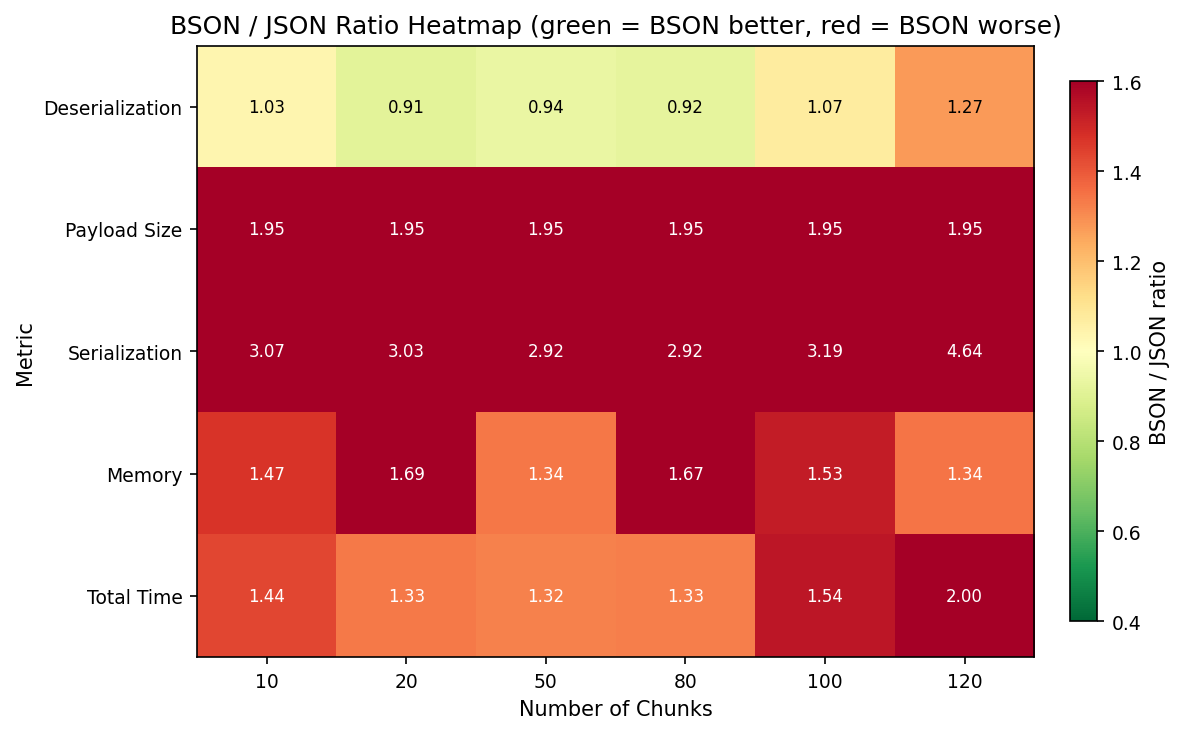

In [32]:
# ── 6b. BSON-to-JSON ratio heatmap across all metrics ─────────
ratio_data = []
metric_cols = {
    'Deserialization': 'deser_mean',
    'Payload Size': 'size_mean',
    'Serialization': 'ser_mean',
    'Memory': 'ram_mean',
    'Total Time': 'total_mean',
}

for nc in common_chunks:
    row_dict = {'numChunks': nc}
    json_row = agg_all[(agg_all['format'] == 'JSON') & (agg_all['numChunks'] == nc)]
    bson_row = agg_all[(agg_all['format'] == 'BSON') & (agg_all['numChunks'] == nc)]
    for label, col in metric_cols.items():
        jv = json_row[col].values[0]
        bv = bson_row[col].values[0]
        row_dict[label] = bv / jv if jv > 0 else np.nan
    ratio_data.append(row_dict)

ratio_df = pd.DataFrame(ratio_data).set_index('numChunks')

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(ratio_df.values.T, aspect='auto', cmap='RdYlGn_r', vmin=0.4, vmax=1.6)
ax.set_xticks(range(len(common_chunks))); ax.set_xticklabels(common_chunks)
ax.set_yticks(range(len(ratio_df.columns))); ax.set_yticklabels(ratio_df.columns)
ax.set_xlabel('Number of Chunks'); ax.set_ylabel('Metric')
ax.set_title('BSON / JSON Ratio Heatmap (green = BSON better, red = BSON worse)')
# annotate
for i in range(ratio_df.shape[1]):
    for j in range(ratio_df.shape[0]):
        ax.text(j, i, f'{ratio_df.values[j, i]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(ratio_df.values[j, i] - 1) > 0.3 else 'black')
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='BSON / JSON ratio')
fig.tight_layout(); savefig(fig, '6b_ratio_heatmap')
plt.show()

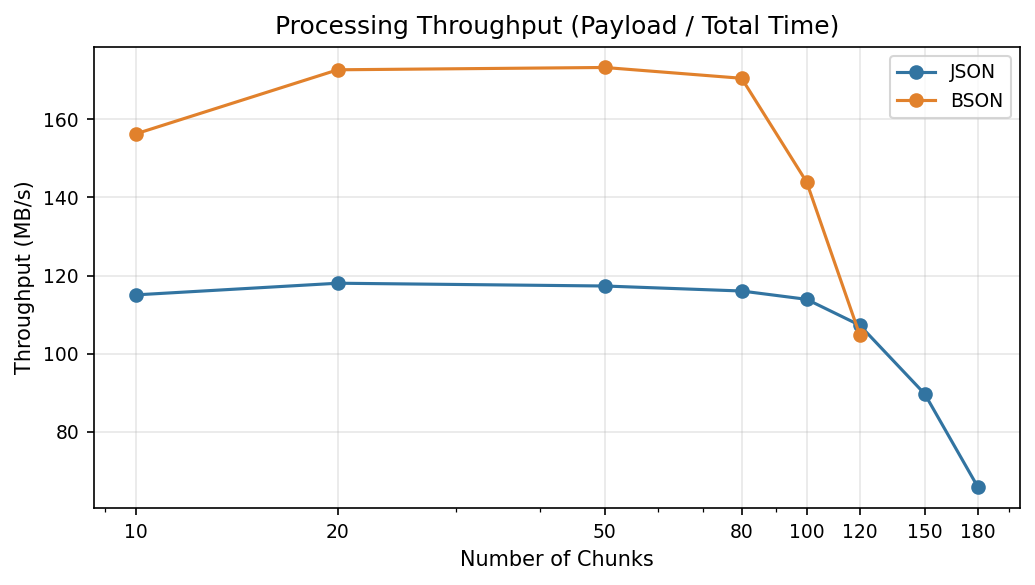

In [33]:
# ── 6c. Throughput: MB/s processed (total) ────────────────────
tp = agg_all.copy()
tp['throughput_MBps'] = (tp['size_mean'] / 1024) / (tp['total_mean'] / 1000)  # MB / seconds

fig, ax = plt.subplots(figsize=(7, 4))
for fmt in formats:
    d = tp[tp['format'] == fmt].sort_values('numChunks')
    ax.plot(d['numChunks'], d['throughput_MBps'], marker='o',
            label=fmt, color=COLORS[fmt], linewidth=1.5)
ax.set_xscale('log')
ax.set_xticks(chunks); ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.set_xlabel('Number of Chunks'); ax.set_ylabel('Throughput (MB/s)')
ax.set_title('Processing Throughput (Payload / Total Time)')
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout(); savefig(fig, '6c_throughput')
plt.show()

In [34]:
# ── 6d. Summary table ─────────────────────────────────────────
summary_rows = []
for nc in common_chunks:
    j = agg_all[(agg_all['format'] == 'JSON') & (agg_all['numChunks'] == nc)].iloc[0]
    b = agg_all[(agg_all['format'] == 'BSON') & (agg_all['numChunks'] == nc)].iloc[0]
    summary_rows.append({
        'Chunks': nc,
        'JSON Deser (ms)': f"{j['deser_mean']:.1f}",
        'BSON Deser (ms)': f"{b['deser_mean']:.1f}",
        'Deser Δ%': f"{(1 - b['deser_mean']/j['deser_mean'])*100:+.1f}%",
        'JSON Size (KB)': f"{j['size_mean']:.0f}",
        'BSON Size (KB)': f"{b['size_mean']:.0f}",
        'Size Δ%': f"{(1 - b['size_mean']/j['size_mean'])*100:+.1f}%",
        'JSON RAM (MB)': f"{j['ram_mean']:.0f}",
        'BSON RAM (MB)': f"{b['ram_mean']:.0f}",
    })
summary = pd.DataFrame(summary_rows)
display(summary.style.set_caption('Summary: JSON vs BSON across chunk sizes'))

,Chunks,JSON Deser (ms),BSON Deser (ms),Deser Δ%,JSON Size (KB),BSON Size (KB),Size Δ%,JSON RAM (MB),BSON RAM (MB)
0,10,472.5,488.7,-3.4%,72222,140811,-95.0%,430,632
1,20,935.3,855.5,+8.5%,144441,281622,-95.0%,747,1263
2,50,2364.9,2215.5,+6.3%,361107,704054,-95.0%,1695,2271
3,80,3779.3,3486.0,+7.8%,577769,1126486,-95.0%,2251,3770
4,100,4766.2,5109.7,-7.2%,722212,1408107,-95.0%,2742,4193
5,120,6179.4,7870.2,-27.4%,866659,1689729,-95.0%,3353,4503
